#Library

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import numpy as np

pd.set_option('display.max_columns', 24)

#Dataset

In [ ]:
fast_food = pd.read_csv('/content/drive/MyDrive/kulyeah/visualisasi data smt 2/Datafiniti_Fast_Food_Restaurants_Jun19.csv')
fast_food.head()

,id,dateAdded,dateUpdated,address,categories,primaryCategories,city,country,keys,latitude,longitude,name,postalCode,province,sourceURLs,websites
0,AWrSh_KgsVYjT2BJAzaH,2019-05-19T23:58:05Z,2019-05-19T23:58:05Z,2555 11th Avenue,"Fast Food Restaurants,Hamburgers and Hot Dogs,...",Accommodation & Food Services,Greeley,US,us/co/greeley/255511thavenue/554191587,40.39629,-104.69699,Carl's Jr.,80631,CO,https://www.yellowpages.com/greeley-co/mip/car...,https://www.carlsjr.com/?utm_source=Yextandutm...
1,AWEKlA-LIxWefVJwxG9B,2018-01-18T18:30:23Z,2019-05-19T23:45:05Z,2513 Highway 6 And 50,"Restaurant,Mexican Restaurants,Fast Food Resta...",Accommodation & Food Services,Grand Junction,US,us/co/grandjunction/2513highway6and50/1550891556,39.08135,-108.58689,Del Taco,81505,CO,http://www.citysearch.com/profile/772076870/gr...,http://www.deltaco.com
2,AWrSfAcYsVYjT2BJAzPt,2019-05-19T23:45:04Z,2019-05-19T23:45:04Z,1125 Patterson Road,"Sandwich Shops,Fast Food Restaurants,Restauran...",Accommodation & Food Services,Grand Junction,US,us/co/grandjunction/1125pattersonroad/-2137447852,39.09148,-108.55411,Which Wich,81506,CO,https://www.yellowpages.com/grand-junction-co/...,http://www.whichwich.com
3,AWrSa3NAQTFama1Xpkbz,2019-05-19T23:26:58Z,2019-05-19T23:26:58Z,3455 N Salida Court,"Fast Food Restaurants,Mexican Restaurants,Rest...",Accommodation & Food Services,Aurora,US,us/co/aurora/3455nsalidacourt/1143321601,39.76369,-104.77671,Chipotle Mexican Grill,80011,CO,https://www.yellowpages.com/aurora-co/mip/chip...,http://www.chipotle.com
4,AWrSaVGzZ4Yw-wtdgcaB,2019-05-19T23:24:38Z,2019-05-19T23:24:38Z,5225 E Colfax Avenue,"Fast Food Restaurants,Mexican Restaurants,Rest...",Accommodation & Food Services,Denver,US,us/co/denver/5225ecolfaxavenue/-864103396,39.74044,-104.92636,Taco Bell,80220,CO,https://www.yellowpages.com/denver-co/mip/taco...,https://locations.tacobell.com/co/denver/5225-...


In [ ]:
diabetes = pd.read_csv('/content/drive/MyDrive/kulyeah/visualisasi data smt 2/DiabetesAtlas_NationalData.csv', sep=';')
diabetes.head()

,Year,Total - Percentage,Total - 95% Lower Limit,Total - 95% Upper Limit
0,2000,6.0,5.7,6.3
1,2001,6.4,6.1,6.8
2,2002,6.5,6.2,6.8
3,2003,6.6,6.3,6.9
4,2004,7.0,6.7,7.3


#Data Description and Information

In [ ]:
fast_food.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 10000 non-null  object 
 1   dateAdded          10000 non-null  object 
 2   dateUpdated        10000 non-null  object 
 3   address            10000 non-null  object 
 4   categories         10000 non-null  object 
 5   primaryCategories  10000 non-null  object 
 6   city               10000 non-null  object 
 7   country            10000 non-null  object 
 8   keys               10000 non-null  object 
 9   latitude           10000 non-null  float64
 10  longitude          10000 non-null  float64
 11  name               10000 non-null  object 
 12  postalCode         10000 non-null  object 
 13  province           10000 non-null  object 
 14  sourceURLs         10000 non-null  object 
 15  websites           9918 non-null   object 
dtypes: float64(2), object(1

In [ ]:
diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Year                     23 non-null     int64  
 1   Total - Percentage       23 non-null     float64
 2   Total - 95% Lower Limit  23 non-null     float64
 3   Total - 95% Upper Limit  23 non-null     float64
dtypes: float64(3), int64(1)
memory usage: 864.0 bytes


#preprocessing

In [ ]:
fast_food['dateAdded'] = pd.to_datetime(fast_food['dateAdded'])

In [ ]:
fast_food['dateAdded'].dt.year

0       2019
1       2018
2       2019
3       2019
4       2019
        ... 
9995    2016
9996    2017
9997    2017
9998    2016
9999    2017
Name: dateAdded, Length: 10000, dtype: int32

In [ ]:
fast_food['yearAdded'] = fast_food['dateAdded'].dt.year

In [ ]:
fast_food.head()

,id,dateAdded,dateUpdated,address,categories,primaryCategories,city,country,keys,latitude,longitude,name,postalCode,province,sourceURLs,websites,yearAdded
0,AWrSh_KgsVYjT2BJAzaH,2019-05-19 23:58:05+00:00,2019-05-19T23:58:05Z,2555 11th Avenue,"Fast Food Restaurants,Hamburgers and Hot Dogs,...",Accommodation & Food Services,Greeley,US,us/co/greeley/255511thavenue/554191587,40.39629,-104.69699,Carl's Jr.,80631,CO,https://www.yellowpages.com/greeley-co/mip/car...,https://www.carlsjr.com/?utm_source=Yextandutm...,2019
1,AWEKlA-LIxWefVJwxG9B,2018-01-18 18:30:23+00:00,2019-05-19T23:45:05Z,2513 Highway 6 And 50,"Restaurant,Mexican Restaurants,Fast Food Resta...",Accommodation & Food Services,Grand Junction,US,us/co/grandjunction/2513highway6and50/1550891556,39.08135,-108.58689,Del Taco,81505,CO,http://www.citysearch.com/profile/772076870/gr...,http://www.deltaco.com,2018
2,AWrSfAcYsVYjT2BJAzPt,2019-05-19 23:45:04+00:00,2019-05-19T23:45:04Z,1125 Patterson Road,"Sandwich Shops,Fast Food Restaurants,Restauran...",Accommodation & Food Services,Grand Junction,US,us/co/grandjunction/1125pattersonroad/-2137447852,39.09148,-108.55411,Which Wich,81506,CO,https://www.yellowpages.com/grand-junction-co/...,http://www.whichwich.com,2019
3,AWrSa3NAQTFama1Xpkbz,2019-05-19 23:26:58+00:00,2019-05-19T23:26:58Z,3455 N Salida Court,"Fast Food Restaurants,Mexican Restaurants,Rest...",Accommodation & Food Services,Aurora,US,us/co/aurora/3455nsalidacourt/1143321601,39.76369,-104.77671,Chipotle Mexican Grill,80011,CO,https://www.yellowpages.com/aurora-co/mip/chip...,http://www.chipotle.com,2019
4,AWrSaVGzZ4Yw-wtdgcaB,2019-05-19 23:24:38+00:00,2019-05-19T23:24:38Z,5225 E Colfax Avenue,"Fast Food Restaurants,Mexican Restaurants,Rest...",Accommodation & Food Services,Denver,US,us/co/denver/5225ecolfaxavenue/-864103396,39.74044,-104.92636,Taco Bell,80220,CO,https://www.yellowpages.com/denver-co/mip/taco...,https://locations.tacobell.com/co/denver/5225-...,2019


# Exploration

In [ ]:
fast_food['dateAdded'].describe()

count                                  10000
mean     2017-07-05 22:33:37.240699904+00:00
min                2014-01-07 05:02:14+00:00
25%         2016-04-03 12:18:27.500000+00:00
50%         2017-07-06 18:10:56.500000+00:00
75%      2019-01-30 17:31:04.249999872+00:00
max                2019-05-19 23:58:05+00:00
Name: dateAdded, dtype: object

In [ ]:
fast_food['yearAdded'].unique()

array([2019, 2018, 2017, 2016, 2015, 2014], dtype=int32)

In [ ]:
jumlah_fast_food = fast_food.groupby('yearAdded').count()['name'].to_frame()

In [ ]:
jumlah_fast_food

,name
yearAdded,
2014,36
2015,1370
2016,2671
2017,2550
2018,437
2019,2936


In [ ]:
fast_food.dtypes

id                                object
dateAdded            datetime64[ns, UTC]
dateUpdated                       object
address                           object
categories                        object
primaryCategories                 object
city                              object
country                           object
keys                              object
latitude                         float64
longitude                        float64
name                              object
postalCode                        object
province                          object
sourceURLs                        object
websites                          object
yearAdded                          int32
dtype: object

In [ ]:
jumlah_fast_food.index = jumlah_fast_food.index.astype('str')

In [ ]:
jumlah_fast_food.index

Index(['2014', '2015', '2016', '2017', '2018', '2019'], dtype='object', name='yearAdded')

In [ ]:
diabetes.set_index('Year', inplace=True)

In [ ]:
diabetes.head()

,Total - Percentage,Total - 95% Lower Limit,Total - 95% Upper Limit
Year,,,
2000,6.0,5.7,6.3
2001,6.4,6.1,6.8
2002,6.5,6.2,6.8
2003,6.6,6.3,6.9
2004,7.0,6.7,7.3


In [ ]:
diabetes.iloc[-5:]

,Total - Percentage,Total - 95% Lower Limit,Total - 95% Upper Limit
Year,,,
2018,9.1,8.7,9.6
2019,8.3,8.0,8.7
2020,8.2,7.9,8.6
2021,8.5,8.1,8.8
2022,8.4,8.1,8.8


In [ ]:
percentage_diabetes = diabetes.loc['2014':'2019', 'Total - Percentage'].to_frame()

In [ ]:
percentage_diabetes.index

Index([2014, 2015, 2016, 2017, 2018, 2019], dtype='int64', name='Year')

In [ ]:
percentage_diabetes.index = percentage_diabetes.index.astype('str')

<Axes: xlabel='Year'>

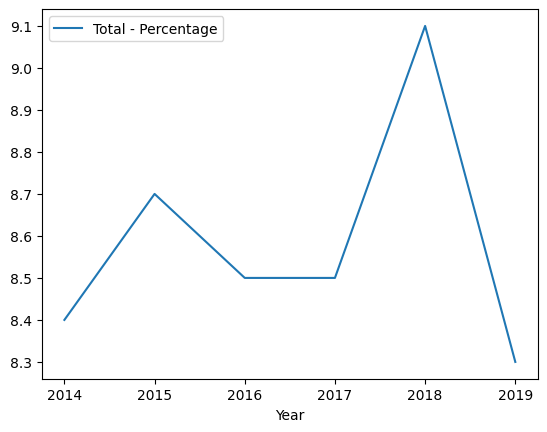

In [ ]:
percentage_diabetes.plot()

# Grafik Line Chart

In [ ]:
jumlah_fast_food

,name
yearAdded,
2014,36
2015,1370
2016,2671
2017,2550
2018,437
2019,2936


In [ ]:
jumlah_fast_food['name'] = (jumlah_fast_food['name']) / 100

In [ ]:
fig = px.line(jumlah_fast_food, y="name",
              title='Jumlah Fast Food yang Ada di US tahun 2014-2019',
              text="name",
              color_discrete_sequence=['#94A684'])
fig.update_traces(textposition="bottom right")
fig.show()

In [ ]:
percentage_diabetes

,Total - Percentage
Year,
2014,8.4
2015,8.7
2016,8.5
2017,8.5
2018,9.1
2019,8.3


In [ ]:
fig = px.line(percentage_diabetes, y="Total - Percentage",
              title='Persentase Penderita Diabetes yang Ada di US tahun 2014-2019',
              text="Total - Percentage",
              color_discrete_sequence=['#E1ACAC'])
fig.update_traces(textposition="bottom right")
fig.show()

In [ ]:
gabung = pd.concat([jumlah_fast_food, percentage_diabetes], axis=1)

In [ ]:
gabung.columns = ['fast_food', 'diabetes']

In [ ]:
gabung

,fast_food,diabetes
2014,0.36,8.4
2015,13.70,8.7
2016,26.71,8.5
2017,25.50,8.5
2018,4.37,9.1
2019,29.36,8.3


In [ ]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=gabung.index,
    y=gabung['fast_food'],
    mode="lines+markers+text",
    name="Persentase Fast Food",
    text=gabung['fast_food'],  # Tambahkan nilai pada setiap titik
    textposition="top center",
    line=dict(color='#94A684'),  # Ubah warna garis menjadi hijau
    marker=dict(color='#94A684')
))

fig.add_trace(go.Scatter(
    x=gabung.index,
    y=gabung['diabetes'],
    mode="lines+markers+text",
    name="Persentase Pasien Diabetes",
    text=gabung['diabetes'],  # Tambahkan nilai pada setiap titik
    textposition="top center",
    line=dict(color='#E1ACAC'),  # Ubah warna garis menjadi hijau
    marker=dict(color='#E1ACAC')
))

fig.update_layout(title='Perbandingan Persentase Diabetes dan Fast Food Tahun 2014-2019')

fig.show()

In [ ]:
fig = px.line(jumlah_fast_food, y="name", text="name")

fig.add_trace(px.line(percentage_diabetes, y="Total - Percentage",
              text="Total - Percentage",
              color_discrete_sequence=['red']).data[0])
fig.update_traces(textposition="bottom right")
fig.update_xaxes(title_text='Tahun')
fig.update_yaxes(title_text='Persentase')
fig.update_layout(title='Perbandingan Persentase Diabetes dan Fast Food')

In [ ]:
fig = px.line(gabung, y=['fast_food', 'diabetes'], markers=True)

# Tambahkan nilai pada setiap titik
fig.update_traces(textposition='top center', mode='lines+markers+text')

# Tampilkan grafik
fig.show()